In [547]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
import numpy as np

In [612]:
main_dir = "../Data/bad_pixel/raw"
main_dir = "/Users/rma145/Desktop/thermo-smoking/Data/Wild_structured/P0/clean/"
main_dir = "/Users/rma145/Desktop/thermo-smoking/Data/Wild_structured/P0/raw/"
# main_dir = "../Data/Raw_Pixels/"
# main_dir = "../Data/static_ta/"

In [613]:
files = os.listdir(main_dir)
files = [os.path.join(main_dir,f) for f in files if f.endswith(".csv")]

/Users/rma145/Desktop/thermo-smoking/Data/Wild_structured/P0/raw/1612978.csv


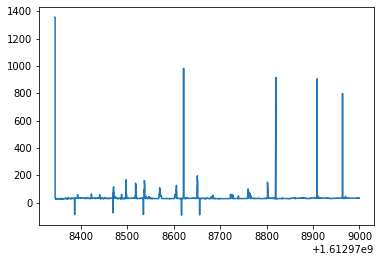

/Users/rma145/Desktop/thermo-smoking/Data/Wild_structured/P0/raw/1612979.csv


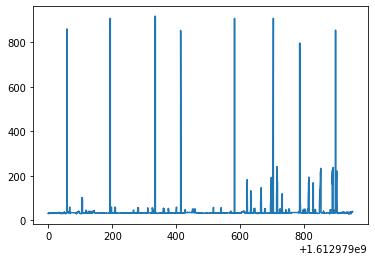

In [614]:
for f in files:
    print(f)
    hour_data = pd.read_csv(f,header=None, index_col=0)
    hour_data.index = hour_data.index.astype(int)
    hour_data = hour_data.drop(1,axis=1)
    plt.plot(hour_data.max(axis=1))
    plt.show()

In [615]:
# hour_data= hour_data[1:]

In [616]:
def bad_row(row):
    left_edge = row[0::32].values
    bad_pixel = np.where(left_edge == left_edge.max())[0][-1]
    if bad_pixel == 0 or left_edge[bad_pixel] < 50:
        return -1
    else:
        return bad_pixel

In [617]:
hour_data[hour_data.apply(bad_row,axis=1) != -1].max(axis=1)

0
1612979058    859.15
1612979059    859.15
1612979059    859.15
1612979059    859.15
1612979067     59.53
1612979193    906.72
1612979194    906.72
1612979194    906.72
1612979311     54.90
1612979311     54.90
1612979311     54.90
1612979334    916.51
1612979334    916.51
1612979335    916.51
1612979401     59.48
1612979401     59.48
1612979401     59.48
1612979414    852.33
1612979516     57.52
1612979517     57.52
1612979517     57.52
1612979541     56.42
1612979582    906.36
1612979583    906.36
1612979583    906.36
1612979583    906.36
1612979704    907.46
1612979704    907.46
1612979704    907.46
1612979786    795.76
1612979786    795.76
1612979787    795.76
1612979898    853.28
1612979899    853.28
1612979899    853.28
1612979899    853.28
dtype: float64

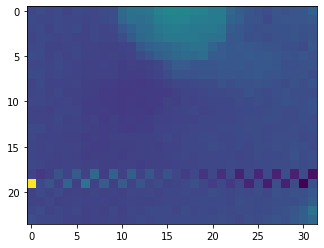

In [627]:
before_data = hour_data.loc[1612979517].values[2]
error_data = hour_data.loc[1612979517].values[1]
plt.imshow(error_data.reshape(24,32))

In [628]:
error_i = np.where(error_data == error_data.max())[0]

In [629]:
error_i

array([608])

In [630]:
before_data[error_i]

array([21.09])

In [631]:
# error_data[error_i] = before_data[error_i]

In [632]:
error_data[error_i]

array([57.52])

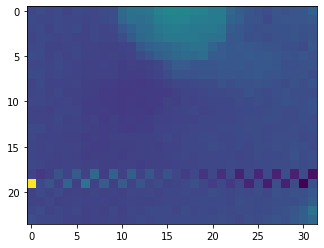

In [633]:
plt.imshow(error_data.reshape(24,32))

In [634]:
# Experment 1
# save raw values
# save params
# plot max of pixels and params 
# check if pixels errors is also a line

In [635]:
# Experment 2
# get the left most pixels column
# identify the bad pixel_i
# Identify the alternating checkbord rows
# Intorpolate with previouse frame 
# intorplate withing current checkboard

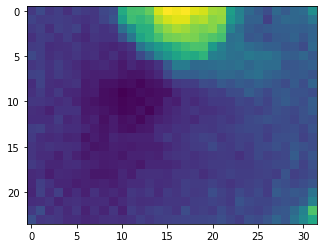

In [636]:
tmp  = error_data.copy()
left_edge = tmp[0::32]
bad_pixel = np.where(left_edge == left_edge.max())[0][0]
bad_row_1 = np.arange(32*bad_pixel,(32*bad_pixel)+32,2)
bad_row_2 = np.arange(32*(bad_pixel-1)+1,(32*(bad_pixel-1))+32,2)
tmp[bad_row_1]=before_data[bad_row_1]
tmp[bad_row_2]=before_data[bad_row_2]
# tmp[bad_row_1]=800
# tmp[bad_row_2]=800
plt.imshow(tmp.reshape(24,32))